In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# Load cleaned dataset

df = pd.read_csv("../processed/cleaned_youtube_data.csv")

df.head()

,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,traffic_source,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours,content_category
0,45.55,2422,88.62,564,Shorts Feed,28.70,1975899,88186,1055,63,1329340.94,Sports
1,59.12,562,15.84,523,Notifications,25.67,1552915,69884,5883,131,242427.29,Vlog
2,40.06,2369,98.56,628,External,10.13,90886,37931,3746,2555,59808.04,News
3,42.54,2097,82.16,239,External,25.00,999294,38861,1575,900,582088.76,Education
4,31.40,1424,75.58,138,Shorts Feed,23.49,1656171,57043,3150,1452,655107.64,Sports


In [4]:
# Independent variables

X = df[
    [
        "video_duration_min",
        "likes",
        "comments"
    ]
]

# Target variable

y = df["avg_view_percentage"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (29999, 3)
Target Shape : (29999,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 23999
Testing Samples : 6000


In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [7]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,video_duration_min,-0.002969
1,likes,-0.000005
2,comments,-0.000073


In [8]:

print("Intercept :", model.intercept_)

Intercept : 50.920611270444354


In [9]:
y_pred = model.predict(X_test)

y_pred[:10]

array([50.52020948, 49.98620015, 50.18022326, 50.28688643, 49.97357283,
       50.13540722, 50.3037815 , 50.67343348, 50.32145066, 50.13506373])

In [10]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 24.9431088916824
Mean Squared Error : 828.5917887821859
Root Mean Squared Error : 28.7852703440872
R² Score : -0.00015091458913207845


In [11]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,81.25,50.520209
1,30.41,49.986200
2,5.31,50.180223
3,65.80,50.286886
4,84.43,49.973573
5,42.06,50.135407
6,80.45,50.303781
7,51.62,50.673433
8,32.64,50.321451
9,3.79,50.135064


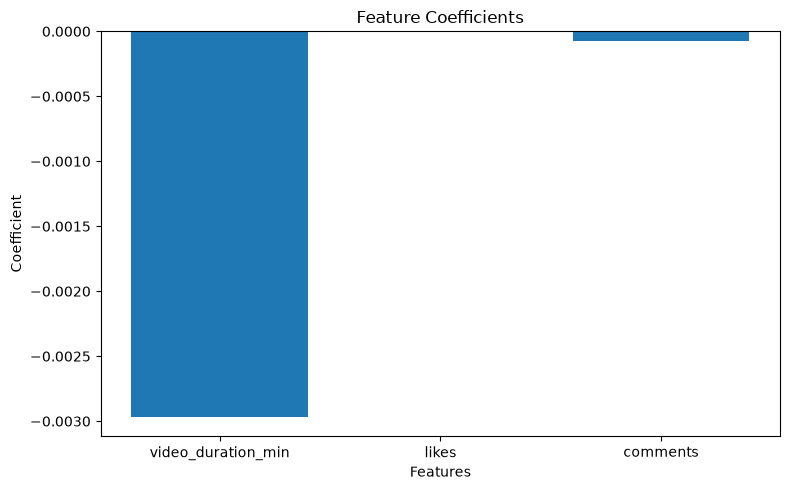

In [12]:
plt.figure(figsize=(8,5))

plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.title("Feature Coefficients")

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.tight_layout()

plt.savefig(
    "../images/multiple_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

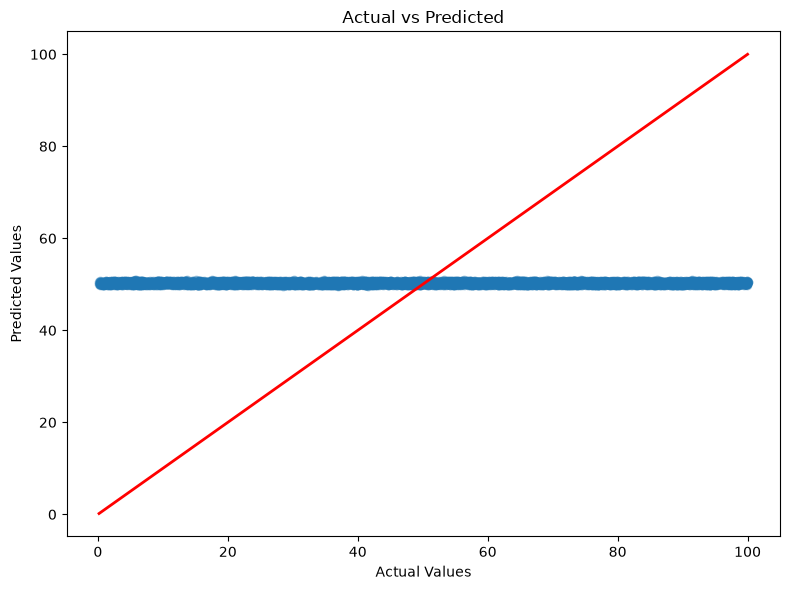

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2
)

plt.tight_layout()

plt.savefig(
    "../images/multiple_regression_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    model,
    "../models/multiple_linear_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.
